# Funções Circulares

**Módulo:** 05 – Trigonometria (2º notebook do módulo)

**Pré-requisitos:** [`01_conjuntos_e_funcoes/`](../01_conjuntos_e_funcoes/) (noção geral de função, domínio, imagem, notação f(x)) e [`0501a_arcos_e_angulos.ipynb`](0501a_arcos_e_angulos.ipynb) (ciclo trigonométrico, radianos, arcos côngruos)

**Objetivos de aprendizagem:**
- Definir as seis funções circulares a partir do ciclo trigonométrico e reconhecer domínio e imagem de cada uma.
- Esboçar e interpretar o gráfico de y = a·sen(bx + c) + d, identificando período, amplitude e deslocamento.
- Determinar o sinal de qualquer função circular em cada quadrante sem usar calculadora.
- Reconhecer fenômenos periódicos do cotidiano e modelá-los com funções circulares.

**Tempo estimado:** 90 a 110 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/05_trigonometria/0502a_funcoes_circulares.ipynb)

## A roda-gigante, agora no tempo

No notebook passado calculamos quantos metros uma cadeira da roda-gigante de 15 metros de raio percorre ao longo do arco depois de girar 50°. Agora pense diferente: se marcarmos o **tempo** no eixo horizontal e a **altura da cadeira acima do chão** no eixo vertical, que formato esse gráfico teria?

A cadeira sobe, desce, sobe de novo — sempre do mesmo jeito, indefinidamente (ou até a roda-gigante parar). Que tipo de função descreve um comportamento assim?

Ainda não temos ferramentas para responder — mas ao final deste notebook (seção 5) a altura da cadeira em função do tempo vai virar uma fórmula concreta, com gráfico e tudo.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    """Aplica o estilo Nord padrão a um eixo do matplotlib."""
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)

## 1. Das Coordenadas do Ciclo às Funções Circulares

No notebook anterior, cada arco (ou ângulo) x virava um ponto (x, y) sobre o ciclo trigonométrico. A pergunta ali era "qual é a coordenada de um arco?".

Agora a pergunta muda: **qual é a função que relaciona cada número real (o arco) a uma coordenada?** Essa mudança de olhar é o que transforma seno e cosseno em **funções de números reais** — não mais só razões associadas a um triângulo retângulo ou a um ângulo específico, mas funções f: ℝ → ℝ que podem ser somadas, compostas, derivadas, e usadas para modelar qualquer coisa que se repete no tempo ou no espaço.

📎 **Conexão:** isso é a mesma construção do ciclo trigonométrico visto em [`0501a_arcos_e_angulos.ipynb`](0501a_arcos_e_angulos.ipynb), seção 7 — só que agora nomeando as coordenadas (x, y) do ponto como funções do arco.

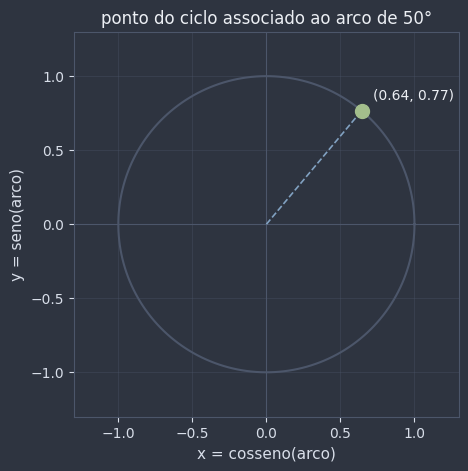

In [2]:
def desenhar_ciclo_com_eixos_nomeados(angulo_graus: float = 50) -> None:
    """Desenha o ciclo trigonométrico rotulando os eixos como cosseno e seno."""
    angulo_rad = math.radians(angulo_graus)
    x, y = math.cos(angulo_rad), math.sin(angulo_rad)

    fig, ax = plt.subplots(figsize=(5, 5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)

    angulos_completos = np.linspace(0, 2 * math.pi, 200)
    ax.plot(np.cos(angulos_completos), np.sin(angulos_completos), color=NORD_LINHA, linewidth=1.5)
    ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
    ax.axvline(0, color=NORD_LINHA, linewidth=0.8)

    ax.plot([0, x], [0, y], color=COR_SECUNDARIA, linewidth=1.2, linestyle="--")
    ax.plot(x, y, "o", color=COR_DESTAQUE, markersize=10)
    ax.annotate(
        f"({x:.2f}, {y:.2f})", (x, y), color=NORD_TEXTO, fontsize=10,
        xytext=(8, 8), textcoords="offset points",
    )

    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_aspect("equal")
    ax.set_xlabel("x = cosseno(arco)", color=NORD_TEXTO_SEC, fontsize=11)
    ax.set_ylabel("y = seno(arco)", color=NORD_TEXTO_SEC, fontsize=11)
    ax.set_title(f"ponto do ciclo associado ao arco de {angulo_graus}°", color=NORD_TEXTO, fontsize=12)
    plt.show()


desenhar_ciclo_com_eixos_nomeados()

**Pergunta de checagem:** por que faz sentido pensar em seno e cosseno como funções, e não apenas como números associados a um ângulo específico?

## 2. Funções Periódicas

Antes de olhar para seno e cosseno, vale entender o fenômeno mais geral que eles representam: coisas que se repetem, sempre do mesmo jeito, em intervalos regulares — as fases da Lua, os batimentos do coração, as estações do ano.

📌 **Definição formal:** uma função f é **periódica** quando existe um número T > 0 tal que

f(x + T) = f(x), para todo x do domínio de f.

Qualquer T que satisfaça essa igualdade é chamado de **período** de f. O menor T positivo com essa propriedade é o **período fundamental** — na prática, quando falamos "o período de f", quase sempre nos referimos a ele.

Periodicidade é um conceito **mais amplo** do que seno e cosseno: qualquer padrão que se repete de forma idêntica é periódico, trigonométrico ou não.

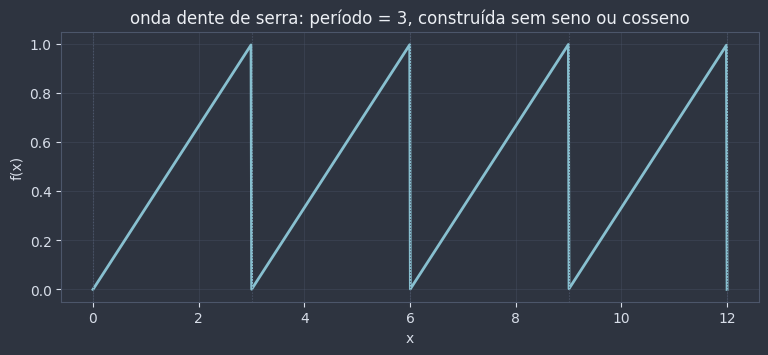

In [3]:
def onda_dente_de_serra(t: np.ndarray, periodo: float) -> np.ndarray:
    """Gera uma onda dente de serra de período `periodo`, sem usar seno ou cosseno."""
    return (t % periodo) / periodo


t = np.linspace(0, 12, 1000)
y = onda_dente_de_serra(t, periodo=3)

fig, ax = plt.subplots(figsize=(9, 3.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(t, y, color=COR_PONTO, linewidth=2)
for k in range(5):
    ax.axvline(k * 3, color=NORD_LINHA, linewidth=0.8, linestyle=":")
ax.set_title("onda dente de serra: período = 3, construída sem seno ou cosseno", color=NORD_TEXTO, fontsize=12)
ax.set_xlabel("x", color=NORD_TEXTO_SEC)
ax.set_ylabel("f(x)", color=NORD_TEXTO_SEC)
plt.show()

**Pergunta de checagem:** se f(x + 5) = f(x) para todo x, o valor 10 também é período de f? E 2,5?

📖 **Leitura complementar:** [Função periódica](https://pt.wikipedia.org/wiki/Fun%C3%A7%C3%A3o_peri%C3%B3dica)

## 3. Função Seno

📌 **Definição formal:** sen(x) é a **ordenada** (coordenada y) do ponto do ciclo trigonométrico associado ao arco x.

- **Domínio:** ℝ (todo número real é um arco válido)
- **Imagem:** [-1, 1] (a ordenada de um ponto do ciclo nunca sai desse intervalo)
- **Período:** 2π
- **Paridade:** função ímpar — sen(-x) = -sen(x) — porque arcos opostos têm pontos simétricos em relação ao eixo x, ou seja, mesma abscissa e ordenadas opostas.

**Representação algébrica:** sen: ℝ → [-1, 1]

**Representação numérica** (ângulos notáveis):

In [4]:
angulos_notaveis_graus = [0, 30, 45, 60, 90, 180, 270, 360]

tabela_seno = pd.DataFrame({
    "x (graus)": angulos_notaveis_graus,
    "x (rad)": [round(math.radians(a), 4) for a in angulos_notaveis_graus],
    "sen(x)": [round(math.sin(math.radians(a)), 4) for a in angulos_notaveis_graus],
})
tabela_seno

,x (graus),x (rad),sen(x)
0,0,0.0000,0.0000
1,30,0.5236,0.5000
2,45,0.7854,0.7071
3,60,1.0472,0.8660
4,90,1.5708,1.0000
5,180,3.1416,0.0000
6,270,4.7124,-1.0000
7,360,6.2832,-0.0000


🕹️ **Widget interativo:** mova o slider de ângulo e observe, ao mesmo tempo, o ponto se deslocando no ciclo trigonométrico (painel esquerdo) e o ponto correspondente sendo traçado no gráfico y = sen(x) (painel direito) — a ordenada é sempre a mesma nos dois painéis.

In [5]:
def sen_e_ciclo(angulo_rad: float) -> None:
    x, y = math.cos(angulo_rad), math.sin(angulo_rad)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax1)
    estilizar_eixo(ax2)

    # painel 1: ciclo trigonométrico, com a ordenada em destaque
    angulos_completos = np.linspace(0, 2 * math.pi, 200)
    ax1.plot(np.cos(angulos_completos), np.sin(angulos_completos), color=NORD_LINHA, linewidth=1.5)
    ax1.axhline(0, color=NORD_LINHA, linewidth=0.8)
    ax1.axvline(0, color=NORD_LINHA, linewidth=0.8)
    ax1.plot([0, x], [0, y], color=COR_SECUNDARIA, linewidth=1.2, linestyle="--")
    ax1.axhline(y, color=COR_PONTO, linewidth=0.8, linestyle=":")
    ax1.plot(x, y, "o", color=COR_DESTAQUE, markersize=10)
    ax1.set_xlim(-1.3, 1.3)
    ax1.set_ylim(-1.3, 1.3)
    ax1.set_aspect("equal")
    ax1.set_title("ciclo trigonométrico", color=NORD_TEXTO, fontsize=12)

    # painel 2: grafico y = sen(x), com o mesmo ponto marcado
    dominio = np.linspace(-0.5, 4 * math.pi, 400)
    ax2.plot(dominio, np.sin(dominio), color=NORD_LINHA, linewidth=1.5)
    ax2.axhline(0, color=NORD_LINHA, linewidth=0.8)
    ax2.plot(angulo_rad, y, "o", color=COR_DESTAQUE, markersize=10)
    ax2.set_ylim(-1.3, 1.3)
    ax2.set_title(f"y = sen(x)     sen({angulo_rad:.2f}) = {y:.2f}", color=NORD_TEXTO, fontsize=12)
    ax2.set_xlabel("x (rad)", color=NORD_TEXTO_SEC)

    plt.show()


widgets.interact(
    sen_e_ciclo,
    angulo_rad=widgets.FloatSlider(min=0, max=2 * math.pi, step=0.1, value=0, description="ângulo (rad)"),
)

interactive(children=(FloatSlider(value=0.0, description='ângulo (rad)', max=6.283185307179586), Output()), _d…

<function __main__.sen_e_ciclo(angulo_rad: float) -> None>

**Pergunta de checagem:** existe algum número real x para o qual sen(x) = 2? Por quê?

📖 **Leitura complementar:** [Senoide](https://pt.wikipedia.org/wiki/Senoide)

## 4. Função Cosseno

📌 **Definição formal:** cos(x) é a **abscissa** (coordenada x) do ponto do ciclo trigonométrico associado ao arco x.

- **Domínio:** ℝ
- **Imagem:** [-1, 1]
- **Período:** 2π
- **Paridade:** função par — cos(-x) = cos(x) — porque arcos opostos têm a mesma abscissa.

Uma relação importante: cos(x) = sen(x + π/2). Ou seja, o cosseno é o próprio seno "adiantado" em π/2 — o mesmo formato de onda, só que deslocado.

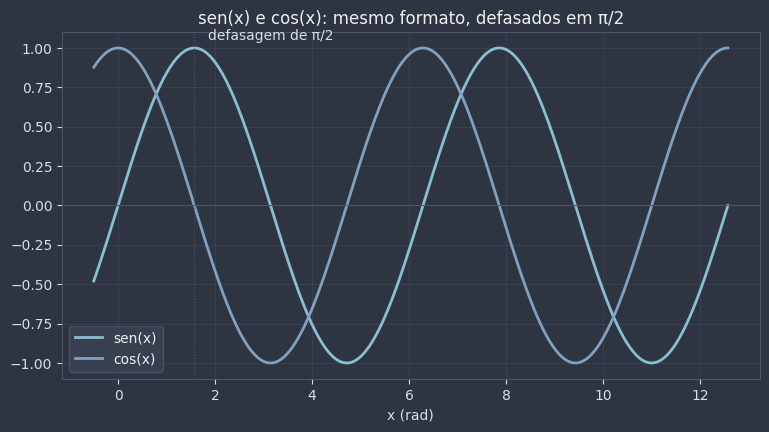

In [6]:
t = np.linspace(-0.5, 4 * math.pi, 400)

fig, ax = plt.subplots(figsize=(9, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)

ax.plot(t, np.sin(t), color=COR_PONTO, linewidth=2, label="sen(x)")
ax.plot(t, np.cos(t), color=COR_SECUNDARIA, linewidth=2, label="cos(x)")
ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
ax.axvline(math.pi / 2, color=NORD_LINHA, linewidth=0.8, linestyle=":")
ax.annotate(
    "defasagem de π/2", (math.pi / 2, 1.05), color=NORD_TEXTO_SEC, fontsize=10,
    xytext=(10, 0), textcoords="offset points",
)

ax.set_title("sen(x) e cos(x): mesmo formato, defasados em π/2", color=NORD_TEXTO, fontsize=12)
ax.set_xlabel("x (rad)", color=NORD_TEXTO_SEC)
legenda = ax.legend(facecolor=NORD_PAINEL, edgecolor=NORD_LINHA, labelcolor=NORD_TEXTO)
plt.show()

💡 **Dica:** para lembrar quem é quem, basta olhar x = 0 — o seno **começa em 0** (sen(0) = 0), o cosseno **começa em 1** (cos(0) = 1).

**Pergunta de checagem:** sem calcular, é possível dizer se cos(x) é par ou ímpar só observando o gráfico? Como?

## 5. Período, Amplitude e Deslocamento

A função seno "pura" (y = sen(x)) é só um caso particular. A forma geral

**y = a·sen(bx + c) + d**

descreve qualquer onda senoidal, e cada parâmetro controla um aspecto diferente do gráfico:

| Parâmetro | Papel | Efeito |
|---|---|---|
| a | amplitude | o quanto a curva "estica" verticalmente — a curva oscila entre d - \|a\| e d + \|a\| |
| b | relacionado ao período | período T = 2π / \|b\| — quanto maior \|b\|, mais rápido a curva oscila |
| c | fase (deslocamento horizontal) | desloca a curva para a esquerda (c > 0) ou direita (c < 0) |
| d | deslocamento vertical | desloca a linha em torno da qual a curva oscila (o "nível médio") |

🕹️ **Widget interativo:** mova os quatro sliders e observe o gráfico de y = a·sen(bx + c) + d mudar em tempo real, com o período e a amplitude atualizados no título.

In [7]:
def grafico_geral_seno(a: float, b: float, c: float, d: float) -> None:
    periodo = 2 * math.pi / abs(b)
    t = np.linspace(-0.5, 4 * math.pi, 500)
    y = a * np.sin(b * t + c) + d

    fig, ax = plt.subplots(figsize=(9, 4.5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)

    ax.plot(t, y, color=COR_PONTO, linewidth=2)
    ax.axhline(d, color=NORD_LINHA, linewidth=1, linestyle=":")
    ax.set_ylim(-6.5, 6.5)
    ax.set_title(
        f"y = {a:.1f}·sen({b:.1f}x + {c:.1f}) + {d:.1f}    "
        f"amplitude = {abs(a):.2f}   período = {periodo:.2f}",
        color=NORD_TEXTO, fontsize=11,
    )
    ax.set_xlabel("x", color=NORD_TEXTO_SEC)
    plt.show()


widgets.interact(
    grafico_geral_seno,
    a=widgets.FloatSlider(min=-3, max=3, step=0.5, value=1, description="a"),
    b=widgets.FloatSlider(min=0.2, max=3, step=0.2, value=1, description="b"),
    c=widgets.FloatSlider(min=-math.pi, max=math.pi, step=0.2, value=0, description="c"),
    d=widgets.FloatSlider(min=-3, max=3, step=0.5, value=0, description="d"),
)

interactive(children=(FloatSlider(value=1.0, description='a', max=3.0, min=-3.0, step=0.5), FloatSlider(value=…

<function __main__.grafico_geral_seno(a: float, b: float, c: float, d: float) -> None>

⚠️ **Erro comum:** achar que o período é diretamente igual a b. Na verdade **T = 2π / \|b\|** — aumentar b **diminui** o período (a curva oscila mais rápido), não aumenta.

**Pergunta de checagem:** se dobrarmos o valor de a e mantivermos os outros parâmetros, o que muda no gráfico: a altura máxima, a largura de um ciclo, ou as duas coisas?

🎯 **Aplicação prática — a roda-gigante do gancho, resolvida:** a cadeira está presa a um raio R = 15 m, e a roda-gigante completa uma volta em T = 4 minutos. A altura da cadeira em relação ao chão, em função do tempo t (em minutos), é

**h(t) = R·sen(ω·t − π/2) + R**, com ω = 2π / T.

O deslocamento vertical d = R = 15 coloca a oscilação em torno da altura do centro da roda; o "−π/2" na fase garante que a cadeira comece **no chão** (h(0) = 0), subindo. Substituindo os números:

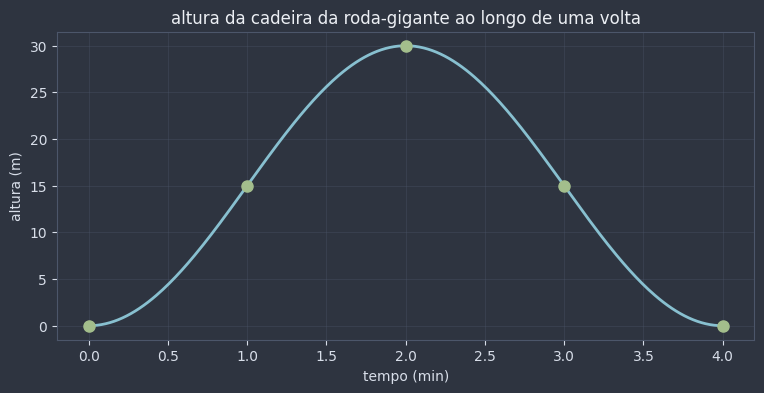

,t (min),h(t) (m)
0,0,0.0
1,1,15.0
2,2,30.0
3,3,15.0
4,4,0.0


In [8]:
raio_roda = 15  # metros
periodo_roda = 4  # minutos
velocidade_angular = 2 * math.pi / periodo_roda  # rad/min


def altura_cadeira(t: float) -> float:
    """Altura da cadeira da roda-gigante (em metros) no instante t (em minutos)."""
    return raio_roda * math.sin(velocidade_angular * t - math.pi / 2) + raio_roda


tempos = np.linspace(0, periodo_roda, 300)
alturas = [altura_cadeira(t) for t in tempos]

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(tempos, alturas, color=COR_PONTO, linewidth=2)

instantes_marcados = [0, 1, 2, 3, 4]
for instante in instantes_marcados:
    ax.plot(instante, altura_cadeira(instante), "o", color=COR_DESTAQUE, markersize=8)

ax.set_title("altura da cadeira da roda-gigante ao longo de uma volta", color=NORD_TEXTO, fontsize=12)
ax.set_xlabel("tempo (min)", color=NORD_TEXTO_SEC)
ax.set_ylabel("altura (m)", color=NORD_TEXTO_SEC)
plt.show()

tabela_roda = pd.DataFrame({
    "t (min)": instantes_marcados,
    "h(t) (m)": [round(altura_cadeira(t), 2) for t in instantes_marcados],
})
tabela_roda

Repare no padrão: a cadeira sai do chão (h = 0), sobe até o topo (h = 30 m, o dobro do raio) na metade da volta, e volta ao chão — exatamente o comportamento periódico que o gancho pedia para explicar.

🎯 **Aplicação secundária:** o mesmo modelo y = a·sen(bx + c) + d serve para contextos bem diferentes. A temperatura ao longo de um dia, por exemplo, também oscila de forma aproximadamente senoidal: mínima de madrugada, máxima no meio da tarde.

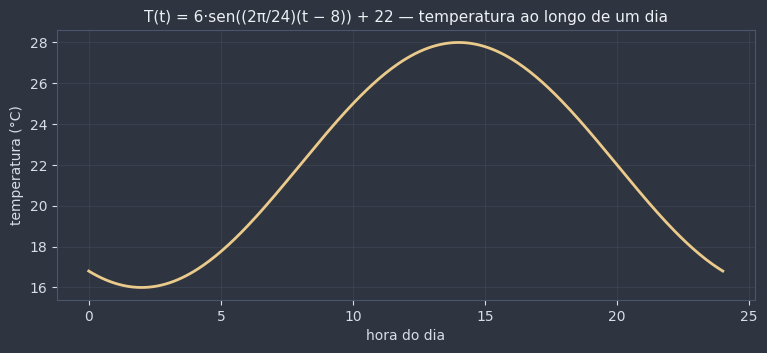

In [9]:
def temperatura(t: float) -> float:
    """Aproximação da temperatura (°C) ao longo de um dia, t em horas (0 a 24)."""
    return 6 * math.sin((2 * math.pi / 24) * (t - 8)) + 22


horas = np.linspace(0, 24, 300)

fig, ax = plt.subplots(figsize=(9, 3.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(horas, [temperatura(h) for h in horas], color=COR_AVISO, linewidth=2)
ax.set_title("T(t) = 6·sen((2π/24)(t − 8)) + 22 — temperatura ao longo de um dia", color=NORD_TEXTO, fontsize=11)
ax.set_xlabel("hora do dia", color=NORD_TEXTO_SEC)
ax.set_ylabel("temperatura (°C)", color=NORD_TEXTO_SEC)
plt.show()

📖 **Leitura complementar:** [Movimento harmônico simples](https://pt.wikipedia.org/wiki/Movimento_harm%C3%B4nico_simples)

## 6. Função Tangente

📌 **Definição formal:** tg(x) = sen(x) / cos(x)

- **Domínio:** ℝ, exceto onde cos(x) = 0, ou seja, x ≠ π/2 + kπ (k inteiro)
- **Imagem:** ℝ (a tangente assume qualquer valor real)
- **Período:** π (a metade do período de seno e cosseno)

Perto de cada ponto excluído do domínio, o denominador cos(x) se aproxima de 0 e tg(x) cresce sem limite — são as **assíntotas verticais** da tangente.

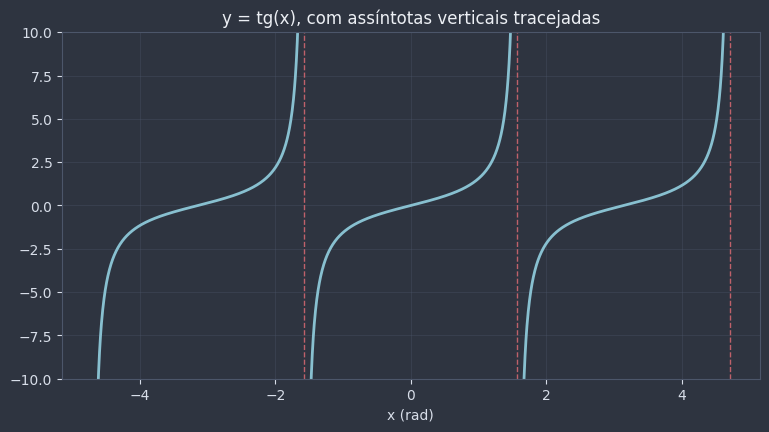

In [10]:
def tangente_com_assintotas(t: np.ndarray) -> np.ndarray:
    """Calcula tg(t), inserindo NaN perto das assíntotas para não conectar os ramos no gráfico."""
    cos_t = np.cos(t)
    y = np.sin(t) / cos_t
    y[np.abs(cos_t) < 0.03] = np.nan
    return y


t = np.linspace(-3 * math.pi / 2, 3 * math.pi / 2, 2000)

fig, ax = plt.subplots(figsize=(9, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(t, tangente_com_assintotas(t), color=COR_PONTO, linewidth=2)

for k in (-1, 0, 1):
    ax.axvline(math.pi / 2 + k * math.pi, color=COR_ALERTA, linewidth=1, linestyle="--")

ax.set_ylim(-10, 10)
ax.set_title("y = tg(x), com assíntotas verticais tracejadas", color=NORD_TEXTO, fontsize=12)
ax.set_xlabel("x (rad)", color=NORD_TEXTO_SEC)
plt.show()

🕹️ **Widget interativo:** mova o slider de ângulo se aproximando de π/2 e observe o valor de tg(x) crescer sem limite.

In [ ]:
def aproximar_assintota_tangente(angulo_rad: float) -> None:
    valor = math.tan(angulo_rad)

    t = np.linspace(0, 1.5, 300)
    fig, ax = plt.subplots(figsize=(8, 4))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.plot(t, np.tan(t), color=NORD_LINHA, linewidth=1.5)
    ax.axvline(math.pi / 2, color=COR_ALERTA, linewidth=1, linestyle="--")
    ax.plot(angulo_rad, valor, "o", color=COR_DESTAQUE, markersize=10)
    ax.set_ylim(0, 20)
    ax.set_title(f"tg({angulo_rad:.4f}) = {valor:.2f}   (π/2 ≈ 1.5708)", color=NORD_TEXTO, fontsize=12)
    ax.set_xlabel("x (rad)", color=NORD_TEXTO_SEC)
    plt.show()


widgets.interact(
    aproximar_assintota_tangente,
    angulo_rad=widgets.FloatSlider(min=0, max=1.55, step=0.01, value=0, description="ângulo (rad)"),
)

interactive(children=(FloatSlider(value=0.0, description='ângulo (rad)', max=1.55, step=0.01), Output()), _dom…

<function __main__.aproximar_assintota_tangente(angulo_rad: float) -> None>

⚠️ **Erro comum:** tentar calcular tg(90°) e não entender por que a calculadora "trava". Não é um erro da calculadora — 90° simplesmente **não está no domínio** da tangente.

**Pergunta de checagem:** por que o período da tangente é π, e não 2π como o do seno e do cosseno?

## 7. Função Cotangente

📌 **Definição formal:** cotg(x) = cos(x) / sen(x) = 1 / tg(x)

- **Domínio:** ℝ, exceto onde sen(x) = 0, ou seja, x ≠ kπ (k inteiro)
- **Imagem:** ℝ
- **Período:** π

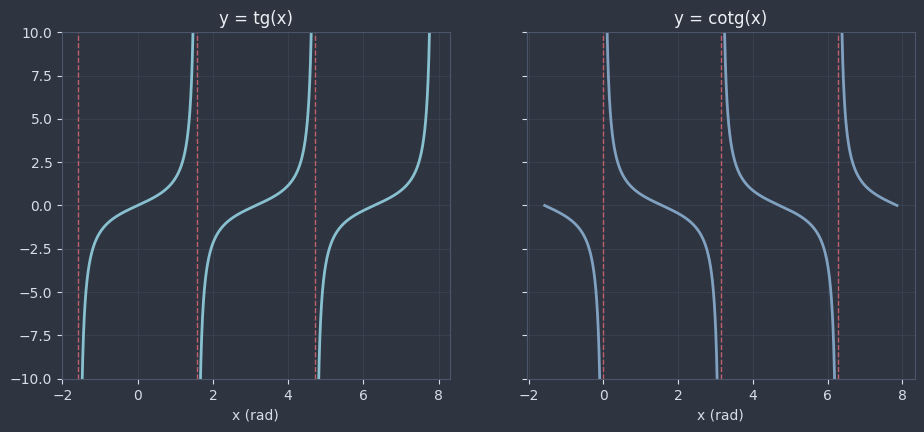

In [12]:
def cotangente_com_assintotas(t: np.ndarray) -> np.ndarray:
    """Calcula cotg(t), inserindo NaN perto das assíntotas."""
    sen_t = np.sin(t)
    y = np.cos(t) / sen_t
    y[np.abs(sen_t) < 0.03] = np.nan
    return y


t = np.linspace(-math.pi / 2, 5 * math.pi / 2, 2000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax1)
estilizar_eixo(ax2)

ax1.plot(t, tangente_com_assintotas(t.copy()), color=COR_PONTO, linewidth=2)
for k in (0, 1, 2):
    ax1.axvline(math.pi / 2 + (k - 1) * math.pi, color=COR_ALERTA, linewidth=1, linestyle="--")
ax1.set_title("y = tg(x)", color=NORD_TEXTO, fontsize=12)
ax1.set_xlabel("x (rad)", color=NORD_TEXTO_SEC)

ax2.plot(t, cotangente_com_assintotas(t.copy()), color=COR_SECUNDARIA, linewidth=2)
for k in (0, 1, 2):
    ax2.axvline(k * math.pi, color=COR_ALERTA, linewidth=1, linestyle="--")
ax2.set_title("y = cotg(x)", color=NORD_TEXTO, fontsize=12)
ax2.set_xlabel("x (rad)", color=NORD_TEXTO_SEC)

for ax in (ax1, ax2):
    ax.set_ylim(-10, 10)
plt.show()

💡 **Dica:** a cotangente é o "inverso multiplicativo" da tangente — mesma lógica que vamos ver a seguir com secante/cossecante em relação a cosseno/seno.

**Pergunta de checagem:** em quais valores de x a função cotangente não está definida, no intervalo de 0 a 2π?

## 8. Função Secante

📌 **Definição formal:** sec(x) = 1 / cos(x)

- **Domínio:** ℝ, exceto onde cos(x) = 0, ou seja, x ≠ π/2 + kπ
- **Imagem:** (-∞, -1] ∪ [1, +∞)
- **Período:** 2π

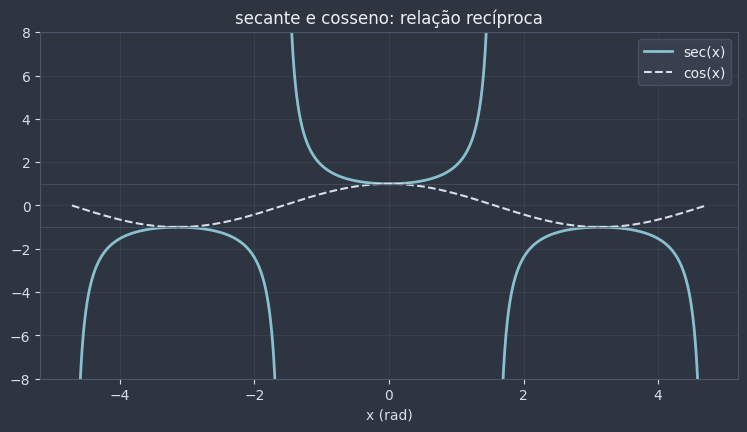

In [13]:
def secante_com_assintotas(t: np.ndarray) -> np.ndarray:
    """Calcula sec(t), inserindo NaN perto das assíntotas."""
    cos_t = np.cos(t)
    y = 1 / cos_t
    y[np.abs(cos_t) < 0.05] = np.nan
    return y


t = np.linspace(-3 * math.pi / 2, 3 * math.pi / 2, 2000)

fig, ax = plt.subplots(figsize=(9, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)

ax.plot(t, secante_com_assintotas(t.copy()), color=COR_PONTO, linewidth=2, label="sec(x)")
ax.plot(t, np.cos(t), color=NORD_TEXTO_SEC, linewidth=1.5, linestyle="--", label="cos(x)")
ax.axhline(1, color=NORD_LINHA, linewidth=0.5)
ax.axhline(-1, color=NORD_LINHA, linewidth=0.5)

ax.set_ylim(-8, 8)
ax.set_title("secante e cosseno: relação recíproca", color=NORD_TEXTO, fontsize=12)
ax.set_xlabel("x (rad)", color=NORD_TEXTO_SEC)
ax.legend(facecolor=NORD_PAINEL, edgecolor=NORD_LINHA, labelcolor=NORD_TEXTO)
plt.show()

🕵️ **Curiosidade histórica:** o nome "secante" vem da geometria clássica — a reta secante que corta a circunferência em dois pontos. A função herdou o nome porque, geometricamente, sec(x) pode ser construída como o comprimento de um segmento sobre uma reta secante ao ciclo trigonométrico.

**Pergunta de checagem:** por que a imagem da secante nunca inclui valores entre -1 e 1?

## 9. Função Cossecante

📌 **Definição formal:** cossec(x) = 1 / sen(x)

- **Domínio:** ℝ, exceto onde sen(x) = 0, ou seja, x ≠ kπ
- **Imagem:** (-∞, -1] ∪ [1, +∞)
- **Período:** 2π

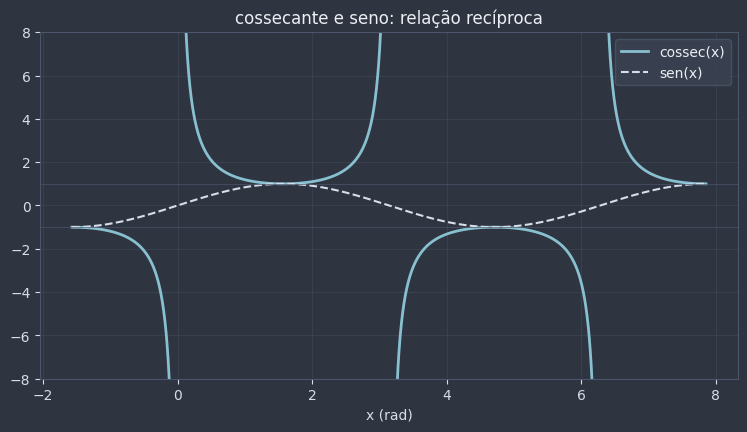

In [14]:
def cossecante_com_assintotas(t: np.ndarray) -> np.ndarray:
    """Calcula cossec(t), inserindo NaN perto das assíntotas."""
    sen_t = np.sin(t)
    y = 1 / sen_t
    y[np.abs(sen_t) < 0.05] = np.nan
    return y


t = np.linspace(-math.pi / 2, 5 * math.pi / 2, 2000)

fig, ax = plt.subplots(figsize=(9, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)

ax.plot(t, cossecante_com_assintotas(t.copy()), color=COR_PONTO, linewidth=2, label="cossec(x)")
ax.plot(t, np.sin(t), color=NORD_TEXTO_SEC, linewidth=1.5, linestyle="--", label="sen(x)")
ax.axhline(1, color=NORD_LINHA, linewidth=0.5)
ax.axhline(-1, color=NORD_LINHA, linewidth=0.5)

ax.set_ylim(-8, 8)
ax.set_title("cossecante e seno: relação recíproca", color=NORD_TEXTO, fontsize=12)
ax.set_xlabel("x (rad)", color=NORD_TEXTO_SEC)
ax.legend(facecolor=NORD_PAINEL, edgecolor=NORD_LINHA, labelcolor=NORD_TEXTO)
plt.show()

📎 **Conexão:** secante e cossecante formam um par recíproco de cosseno e seno, do mesmo jeito que tangente e cotangente formam outro par recíproco entre si.

**Pergunta de checagem:** secante e cossecante têm o mesmo período que tangente e cotangente? Compare os quatro períodos.

## 10. Sinal das Funções por Quadrante

Como tangente, cotangente, secante e cossecante são todas derivadas de seno e cosseno, o sinal (positivo ou negativo) de qualquer uma das seis funções em um ponto pode ser deduzido a partir do sinal de sen(x) e cos(x) naquele ponto — não precisa ser decorado, pode ser reconstruído.

📌 **Regra mnemônica (T-S-T-C):** lendo os quadrantes I, II, III, IV em ordem — **T**odos positivos, **S**ó seno (e cossecante), **S**ó tangente (e cotangente), **S**ó cosseno (e secante).

In [15]:
def sinal(valor: float) -> str:
    """Classifica o sinal de um valor como positivo, negativo ou zero."""
    if valor > 0:
        return "+"
    if valor < 0:
        return "-"
    return "0"


quadrantes_referencia = {
    "I (0° a 90°)": math.radians(45),
    "II (90° a 180°)": math.radians(135),
    "III (180° a 270°)": math.radians(225),
    "IV (270° a 360°)": math.radians(315),
}

funcoes_circulares = {
    "sen": math.sin,
    "cos": math.cos,
    "tg": lambda x: math.sin(x) / math.cos(x),
    "cotg": lambda x: math.cos(x) / math.sin(x),
    "sec": lambda x: 1 / math.cos(x),
    "cossec": lambda x: 1 / math.sin(x),
}

tabela_sinais = pd.DataFrame(
    {nome_q: [sinal(f(angulo)) for f in funcoes_circulares.values()] for nome_q, angulo in quadrantes_referencia.items()},
    index=list(funcoes_circulares.keys()),
)
tabela_sinais

,I (0° a 90°),II (90° a 180°),III (180° a 270°),IV (270° a 360°)
sen,+,+,-,-
cos,+,-,-,+
tg,+,-,+,-
cotg,+,-,+,-
sec,+,-,-,+
cossec,+,+,-,-


🕹️ **Widget interativo:** mova o slider de ângulo (0 a 2π) e observe o sinal das seis funções mudando ao vivo, junto com o ponto correspondente no ciclo trigonométrico.

In [16]:
def mostrar_sinais_ao_vivo(angulo_rad: float) -> None:
    x, y = math.cos(angulo_rad), math.sin(angulo_rad)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax1)
    ax2.set_facecolor(NORD_FUNDO)
    ax2.axis("off")

    angulos_completos = np.linspace(0, 2 * math.pi, 200)
    ax1.plot(np.cos(angulos_completos), np.sin(angulos_completos), color=NORD_LINHA, linewidth=1.5)
    ax1.axhline(0, color=NORD_LINHA, linewidth=0.8)
    ax1.axvline(0, color=NORD_LINHA, linewidth=0.8)
    ax1.plot(x, y, "o", color=COR_DESTAQUE, markersize=10)
    ax1.set_xlim(-1.3, 1.3)
    ax1.set_ylim(-1.3, 1.3)
    ax1.set_aspect("equal")
    ax1.set_title(f"ângulo = {angulo_rad:.2f} rad", color=NORD_TEXTO, fontsize=12)

    for i, (nome, f) in enumerate(funcoes_circulares.items()):
        try:
            valor = f(angulo_rad)
        except ZeroDivisionError:
            texto, cor = f"{nome}(x): indefinido (assíntota)", NORD_TEXTO_SEC
        else:
            rotulo = "positivo" if valor > 0 else ("negativo" if valor < 0 else "zero")
            cor = COR_DESTAQUE if valor > 0 else (COR_ALERTA if valor < 0 else NORD_TEXTO_SEC)
            texto = f"{nome}(x) = {valor:.2f}  ->  {rotulo}"
        ax2.text(0.05, 0.85 - i * 0.15, texto, color=cor, fontsize=13, transform=ax2.transAxes)

    plt.show()


widgets.interact(
    mostrar_sinais_ao_vivo,
    angulo_rad=widgets.FloatSlider(min=0, max=2 * math.pi, step=0.05, value=0.5, description="ângulo (rad)"),
)

interactive(children=(FloatSlider(value=0.5, description='ângulo (rad)', max=6.283185307179586, step=0.05), Ou…

<function __main__.mostrar_sinais_ao_vivo(angulo_rad: float) -> None>

**Pergunta de checagem:** no terceiro quadrante, quais das seis funções são positivas?

## Resumo — cheat sheet

| Função | Definição | Domínio | Imagem | Período |
|---|---|---|---|---|
| sen(x) | ordenada do ponto do ciclo | ℝ | [-1, 1] | 2π |
| cos(x) | abscissa do ponto do ciclo | ℝ | [-1, 1] | 2π |
| tg(x) | sen(x) / cos(x) | x ≠ π/2 + kπ | ℝ | π |
| cotg(x) | cos(x) / sen(x) | x ≠ kπ | ℝ | π |
| sec(x) | 1 / cos(x) | x ≠ π/2 + kπ | (-∞,-1] ∪ [1,+∞) | 2π |
| cossec(x) | 1 / sen(x) | x ≠ kπ | (-∞,-1] ∪ [1,+∞) | 2π |

**Forma geral:** y = a·sen(bx + c) + d
- \|a\| = amplitude · b → período T = 2π / \|b\| · c = fase (deslocamento horizontal) · d = deslocamento vertical

**Sinal por quadrante (regra T-S-T-C):** I → todos positivos · II → só seno/cossecante · III → só tangente/cotangente · IV → só cosseno/secante

## Exercícios

**Básico**
1. Calcule sen(x), cos(x) e tg(x) para um ângulo notável.
2. Identifique, para x = 90°, quais das quatro funções tg, cotg, sec, cossec não estão definidas.

**Intermediário**
3. Dada y = a·sen(bx + c) + d, identifique amplitude, período e deslocamento vertical sem plotar o gráfico primeiro.
4. Determine o sinal de tg(200°) sabendo apenas o quadrante do arco, sem calcular o valor exato.

**Desafio**
5. Modele a maré de um porto (altura entre 0,5 m e 2,5 m, ciclo de 12 horas) como uma função y = a·sen(bx + c) + d.
6. Compare os períodos das seis funções circulares e verifique que tangente e cotangente têm o menor período entre elas.

Gabarito completo com resolução passo a passo em [`0502b_funcoes_circulares_gabarito.ipynb`](0502b_funcoes_circulares_gabarito.ipynb) — tente resolver sozinho antes de olhar.

### Básico

In [ ]:
# Exercício Básico 1: calcule sen(x), cos(x) e tg(x) para x = pi/3 (60 graus).
# Guarde a resposta como uma tupla (sen_x, cos_x, tg_x), com cada valor
# arredondado a 4 casas decimais.
angulo_exercicio1 = math.pi / 3
respostas_exercicio1 = ...  # ex: (sen_x, cos_x, tg_x)

print(respostas_exercicio1)

In [ ]:
# Verificação
esperado_exercicio1 = (
    round(math.sin(angulo_exercicio1), 4),
    round(math.cos(angulo_exercicio1), 4),
    round(math.tan(angulo_exercicio1), 4),
)
assert respostas_exercicio1 == esperado_exercicio1, (
    "Tente de novo, revise: calcule sen, cos e tg de pi/3 e arredonde cada valor "
    "a 4 casas decimais, na ordem (sen, cos, tg) (seção 3, 4 e 6 - Funções Seno, Cosseno e Tangente)."
)
print("Certo!")

In [ ]:
# Exercício Básico 2: para x = 90 graus, quais das quatro funções tg, cotg, sec
# e cossec NÃO estão definidas? Guarde a resposta como uma lista de strings,
# em ordem alfabética, ex: ["cotg", "sec"].
respostas_exercicio2 = ...

print(respostas_exercicio2)

In [ ]:
# Verificação
esperado_exercicio2 = sorted(["sec", "tg"])
assert respostas_exercicio2 == esperado_exercicio2, (
    "Tente de novo, revise: em x = 90°, cos(x) = 0. Quais das quatro funções têm "
    "cos(x) no denominador? (seção 6 e 8 - Funções Tangente e Secante)."
)
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 3: para y = 3*sen(2x) + 1, identifique amplitude,
# período e deslocamento vertical, sem plotar o gráfico primeiro.
# Guarde a resposta como uma tupla (amplitude, periodo, deslocamento_vertical),
# com o período arredondado a 4 casas decimais.
respostas_exercicio3 = ...  # ex: (amplitude, periodo, deslocamento_vertical)

print(respostas_exercicio3)

In [ ]:
# Verificação
esperado_exercicio3 = (3, round(2 * math.pi / 2, 4), 1)
assert respostas_exercicio3 == esperado_exercicio3, (
    "Tente de novo, revise: em y = a*sen(bx + c) + d, a amplitude é |a|, o período "
    "é 2*pi/|b| e o deslocamento vertical é d (seção 5 - Período, Amplitude e Deslocamento)."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 4: sem calcular o valor exato, determine o sinal de
# tg(200°) a partir do quadrante do arco. Guarde a resposta como a string
# "positivo" ou "negativo".
resposta_exercicio4 = ...

print(resposta_exercicio4)

In [ ]:
# Verificação
esperado_exercicio4 = "positivo" if math.tan(math.radians(200)) > 0 else "negativo"
assert resposta_exercicio4 == esperado_exercicio4, (
    "Tente de novo, revise: 200° está no terceiro quadrante. Pela regra T-S-T-C, "
    "qual função é positiva nesse quadrante? (seção 10 - Sinal das Funções por Quadrante)."
)
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 5: a maré de um porto varia entre 0,5 m (maré baixa) e
# 2,5 m (maré alta), completando um ciclo a cada 12 horas. Em t = 0, a maré
# está na altura média e subindo. Modele a altura como y = a*sen(bx + c) + d
# e guarde a resposta como uma tupla (a, b, c, d), com b arredondado a 4 casas
# decimais.
respostas_exercicio5 = ...  # ex: (a, b, c, d)

print(respostas_exercicio5)

In [ ]:
# Verificação
esperado_exercicio5 = (1.0, round(2 * math.pi / 12, 4), 0.0, 1.5)
assert respostas_exercicio5 == esperado_exercicio5, (
    "Tente de novo, revise: a = (max - min) / 2, d = (max + min) / 2, b = 2*pi / T "
    "e, como a maré começa na média subindo, c = 0 (seção 5 - Período, Amplitude e Deslocamento)."
)
print("Certo!")

In [ ]:
# Exercício Desafio 6: escreva os períodos das seis funções circulares como um
# dicionário {nome: periodo}, usando math.pi onde necessário, e verifique que
# tangente e cotangente têm o menor período entre as seis.
respostas_exercicio6 = {
    "sen": ...,
    "cos": ...,
    "tg": ...,
    "cotg": ...,
    "sec": ...,
    "cossec": ...,
}

print(respostas_exercicio6)

In [ ]:
# Verificação
esperado_exercicio6 = {
    "sen": 2 * math.pi, "cos": 2 * math.pi, "tg": math.pi,
    "cotg": math.pi, "sec": 2 * math.pi, "cossec": 2 * math.pi,
}
assert respostas_exercicio6 == esperado_exercicio6, (
    "Tente de novo, revise: sen, cos, sec e cossec têm período 2*pi; tg e cotg têm "
    "período pi, a metade (seções 3 a 9 - Funções Circulares)."
)
assert respostas_exercicio6["tg"] < respostas_exercicio6["sen"], (
    "Tente de novo, revise: compare o período de tg com o de sen (seções 3 e 6)."
)
print("Certo!")

## Glossário do bloco

| Termo | Definição |
|---|---|
| Função periódica | função f tal que f(x + T) = f(x) para todo x, sendo T o período |
| Período fundamental | o menor período positivo de uma função periódica |
| sen(x), cos(x) | ordenada e abscissa do ponto do ciclo trigonométrico associado ao arco x |
| tg(x), cotg(x) | razões sen(x)/cos(x) e cos(x)/sen(x); período π |
| sec(x), cossec(x) | inversos 1/cos(x) e 1/sen(x); período 2π |
| Amplitude | \|a\| em y = a·sen(bx + c) + d; o quanto a curva oscila para cima e para baixo |
| Assíntota vertical | reta vertical que o gráfico se aproxima sem tocar, onde a função não está definida |

## Conexões

**Isso depende de:**
- [`01_conjuntos_e_funcoes/`](../01_conjuntos_e_funcoes/) (conceito geral de função, domínio, imagem, notação f(x))
- [`0501a_arcos_e_angulos.ipynb`](0501a_arcos_e_angulos.ipynb) (ciclo trigonométrico, radianos, arcos côngruos)

**Isso será usado em:**
- 📌 Relações Fundamentais (as relações fundamentais, como sen²x + cos²x = 1 e derivadas, partem diretamente das definições construídas aqui)
- 📌 Redução ao 1º Quadrante (a tabela de sinais por quadrante, seção 10, é pré-requisito direto)
- 📌 Transformações (as fórmulas de adição e multiplicação de arcos operam sobre estas mesmas seis funções)
- [`11_limite_integral_e_derivada/`](../11_limite_integral_e_derivada/) (período, domínio e imagem das funções circulares reaparecem ao estudar seus limites e derivadas)